In [18]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pickle
import gzip
import json

## 2. Data Paths Configuration
Define paths to the NavSim dataset and cached training data.

# CARLA-NavSim Data Exploration Notebook

This notebook provides tools to explore and visualize the cached CARLA-NavSim training data used by DiffusionDrive.

## Table of Contents
1. **Setup & Imports** - Load required libraries
2. **Data Paths** - Define paths to raw and cached data
3. **Single Sample Analysis** - Load and visualize one feature/target pair
4. **Feature Visualization** - Detailed visualization of input features
5. **Target Visualization** - Detailed visualization of ground truth targets
6. **Sequence Exploration** - Tools to explore full sequences
7. **Temporal Analysis** - Analyze consistency across time
8. **Scenario Search** - Find specific driving scenarios
9. **Usage Guide** - Summary and examples

## 1. Setup & Imports
Import necessary libraries for data loading and visualization.

In [19]:
navsim_logs_paths = Path("/workspace/navsim_workspace/dataset/navsim_logs/trainval").glob("*.pkl")

# Under the foolder
# CAM_B0  CAM_F0  CAM_L0  CAM_L1  CAM_L2  CAM_R0  CAM_R1  CAM_R2  MergedPointCloud
# CAM is jpg files, MergedPointCloud is pcd file
sensor_logs_paths = Path("/workspace/navsim_workspace/dataset/sensor_blobs/trainval").glob("*")



## 3. Load Raw NavSim Data (Optional)
Load a sample from the raw NavSim pickle files to understand the original data format.

In [20]:
navsim_log_path = next(navsim_logs_paths)
with open(navsim_log_path, "rb") as f:
    navsim_log = pickle.load(f)

In [21]:
# navsim_log[2]


## 4. Load Cached Training Data
Load a single feature-target pair from the cached training data to understand the preprocessed format.

In [22]:
# transfuser_feature.gz  transfuser_target.gza
base_cache_dir = Path("/workspace/navsim_workspace/exp/training_cache/")
transfuser_feature_paths = base_cache_dir.rglob("transfuser_feature*.gz")
transfuser_target_paths = base_cache_dir.rglob("transfuser_target*.gz")

## 5. Inspect Feature Shapes
Display the shapes and structure of the input features (camera, LiDAR, status).

In [23]:
transfuser_feature_path = sorted(list(transfuser_feature_paths))[0]
with gzip.open(transfuser_feature_path, 'rb') as f:
    # Read the entire file content
    transfuser_feature = pickle.load(f)
# show all the files info
print(f"transfuser_feature keys: {transfuser_feature.keys()}")
print(f"{transfuser_feature['camera_feature'].shape=}")
print(f"{transfuser_feature['lidar_feature'].shape=}")
print(f"{transfuser_feature['status_feature'].shape=}")

transfuser_feature keys: dict_keys(['camera_feature', 'lidar_feature', 'status_feature'])
transfuser_feature['camera_feature'].shape=torch.Size([3, 256, 1024])
transfuser_feature['lidar_feature'].shape=torch.Size([1, 256, 256])
transfuser_feature['status_feature'].shape=torch.Size([8])


In [24]:
transfuser_target_path = sorted(list(transfuser_target_paths))[0]
with gzip.open(transfuser_target_path, 'rb') as f:
    transfuser_target = pickle.load(f)
print(f"transfuser_target keys: {transfuser_target.keys()}")
for key, value in transfuser_target.items():
    if hasattr(value, 'shape'):
        print(f"{key}: {value.shape}")
    else:
        print(f"{key}: {type(value)}")

transfuser_target keys: dict_keys(['trajectory', 'agent_states', 'agent_labels', 'bev_semantic_map'])
trajectory: torch.Size([8, 3])
agent_states: torch.Size([30, 5])
agent_labels: torch.Size([30])
bev_semantic_map: torch.Size([128, 256])


## 6. Inspect Target Shapes
Display the shapes and structure of the ground truth targets (trajectory, agents, BEV map).

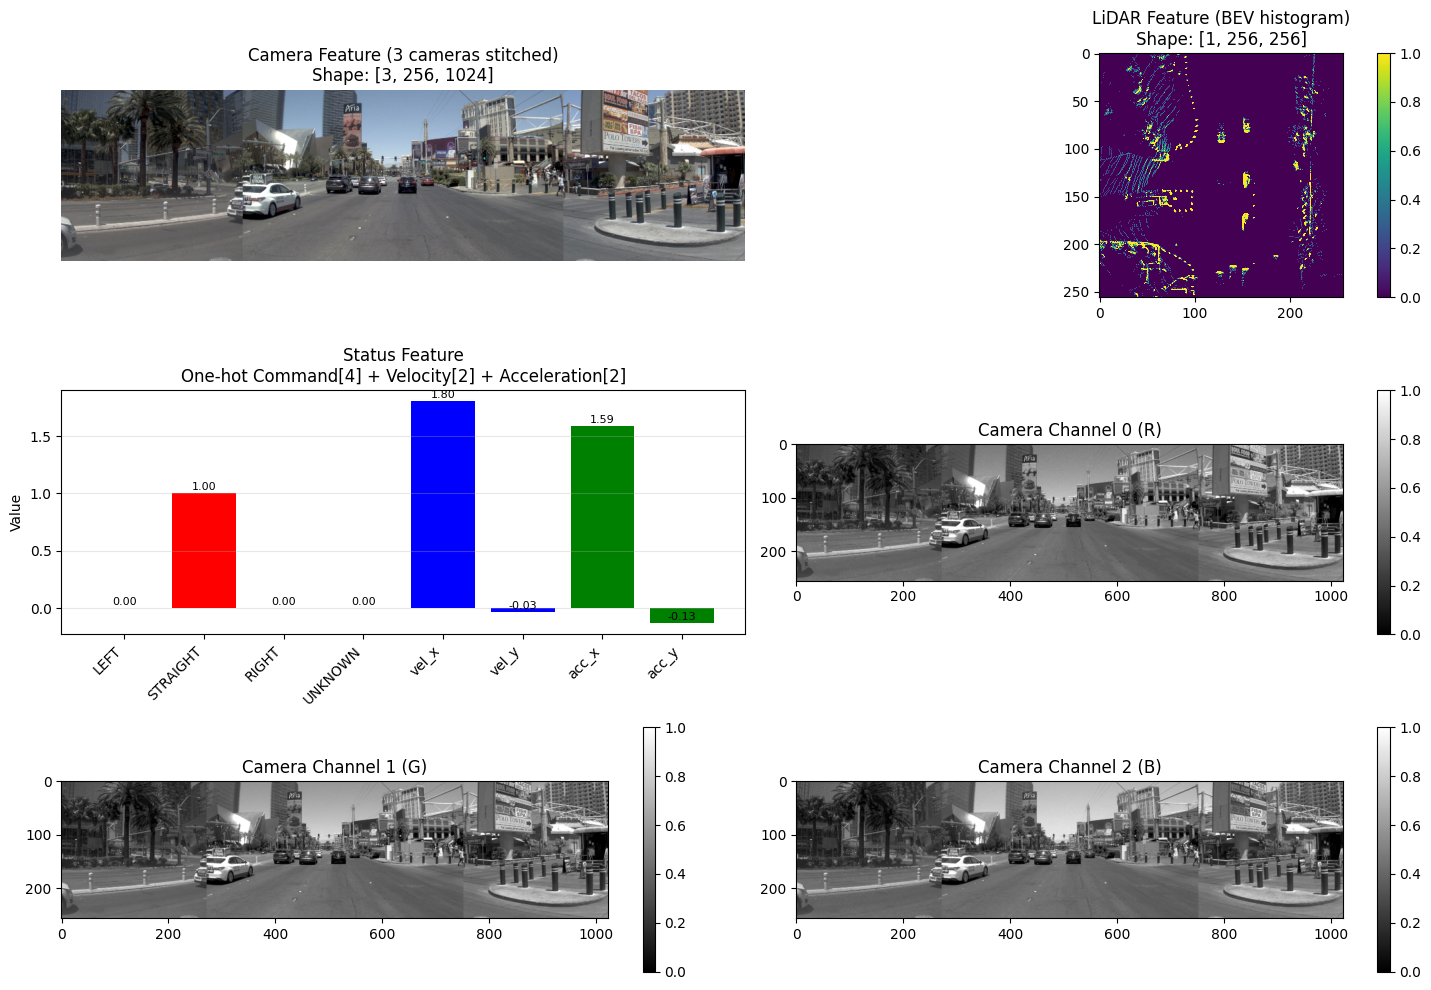


Feature Statistics:
Camera - min: 0.000, max: 1.000, mean: 0.408
LiDAR - min: 0.000, max: 1.000, mean: 0.043
Status - values: [ 0.          1.          0.          0.          1.8030407  -0.03375518
  1.5873523  -0.13237587]

Driving Command (one-hot): [0. 1. 0. 0.]
Active command: STRAIGHT

Velocity (x, y): (1.80, -0.03) m/s
Acceleration (x, y): (1.59, -0.13) m/s²


In [25]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def visualize_transfuser_features(features, figsize=(15, 10)):
    """
    Visualize transfuser features including camera, lidar, and status features.
    
    Args:
        features: Dictionary containing 'camera_feature', 'lidar_feature', 'status_feature'
        figsize: Figure size for the plot
    """
    fig = plt.figure(figsize=figsize)
    
    # 1. Visualize Camera Feature
    # Camera feature shape: [3, 256, 1024] - 3 RGB channels
    camera_feat = features['camera_feature']
    if isinstance(camera_feat, torch.Tensor):
        camera_feat = camera_feat.numpy()
    
    # Transpose from CHW to HWC for visualization
    camera_img = np.transpose(camera_feat, (1, 2, 0))
    
    # Normalize to [0, 1] range if needed
    if camera_img.max() > 1.0:
        camera_img = (camera_img - camera_img.min()) / (camera_img.max() - camera_img.min())
    
    plt.subplot(3, 2, 1)
    plt.imshow(camera_img)
    plt.title('Camera Feature (3 cameras stitched)\nShape: [3, 256, 1024]')
    plt.axis('off')
    
    # 2. Visualize LiDAR Feature
    # LiDAR feature shape: [1, 256, 256] - single channel histogram
    lidar_feat = features['lidar_feature']
    if isinstance(lidar_feat, torch.Tensor):
        lidar_feat = lidar_feat.numpy()
    
    # Remove channel dimension
    lidar_img = lidar_feat.squeeze(0)
    
    plt.subplot(3, 2, 2)
    plt.imshow(lidar_img, cmap='viridis', interpolation='nearest')
    plt.title('LiDAR Feature (BEV histogram)\nShape: [1, 256, 256]')
    plt.colorbar()
    
    # 3. Visualize Status Feature
    # Status feature shape: [8] - one-hot driving_command[4] + velocity[2] + acceleration[2]
    status_feat = features['status_feature']
    if isinstance(status_feat, torch.Tensor):
        status_feat = status_feat.numpy()
    
    # Based on the data, driving_command is already one-hot encoded:
    # [LEFT, STRAIGHT, RIGHT, UNKNOWN] + [vel_x, vel_y] + [acc_x, acc_y]
    
    plt.subplot(3, 2, 3)
    labels = ['LEFT', 'STRAIGHT', 'RIGHT', 'UNKNOWN', 'vel_x', 'vel_y', 'acc_x', 'acc_y']
    colors = ['red', 'red', 'red', 'red', 'blue', 'blue', 'green', 'green']
    bars = plt.bar(range(8), status_feat, color=colors)
    plt.xticks(range(8), labels, rotation=45, ha='right')
    plt.ylabel('Value')
    plt.title('Status Feature\nOne-hot Command[4] + Velocity[2] + Acceleration[2]')
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, status_feat)):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    
    # 4. Show RGB channels separately
    for i in range(3):
        plt.subplot(3, 2, 4 + i)
        channel = camera_feat[i]
        plt.imshow(channel, cmap='gray')
        plt.title(f'Camera Channel {i} ({"RGB"[i]})')
        plt.colorbar()
    
    plt.tight_layout()
    plt.show()
    
    # Print feature statistics
    print("\nFeature Statistics:")
    print(f"Camera - min: {camera_feat.min():.3f}, max: {camera_feat.max():.3f}, mean: {camera_feat.mean():.3f}")
    print(f"LiDAR - min: {lidar_feat.min():.3f}, max: {lidar_feat.max():.3f}, mean: {lidar_feat.mean():.3f}")
    print(f"Status - values: {status_feat}")
    
    # Interpret driving command (one-hot encoded)
    driving_cmd = status_feat[:4]
    print(f"\nDriving Command (one-hot): {driving_cmd}")
    
    # According to driving_command_analysis.md:
    # 0 = LEFT (turns, lane changes, sharp curves)
    # 1 = STRAIGHT
    # 2 = RIGHT (turns, lane changes, sharp curves)
    # 3 = UNKNOWN (can be filtered)
    cmd_names = ['LEFT', 'STRAIGHT', 'RIGHT', 'UNKNOWN']
    active_cmd_idx = np.argmax(driving_cmd)
    if driving_cmd[active_cmd_idx] == 1.0:
        print(f"Active command: {cmd_names[active_cmd_idx]}")
    
    print(f"\nVelocity (x, y): ({status_feat[4]:.2f}, {status_feat[5]:.2f}) m/s")
    print(f"Acceleration (x, y): ({status_feat[6]:.2f}, {status_feat[7]:.2f}) m/s²")

# Call the visualization function
visualize_transfuser_features(transfuser_feature)

## 7. Comprehensive Feature Visualization
Function to visualize all input features in detail:
- Camera: 3 stitched front cameras (RGB channels shown separately)
- LiDAR: BEV histogram of point cloud density
- Status: Driving command (one-hot), velocity, and acceleration

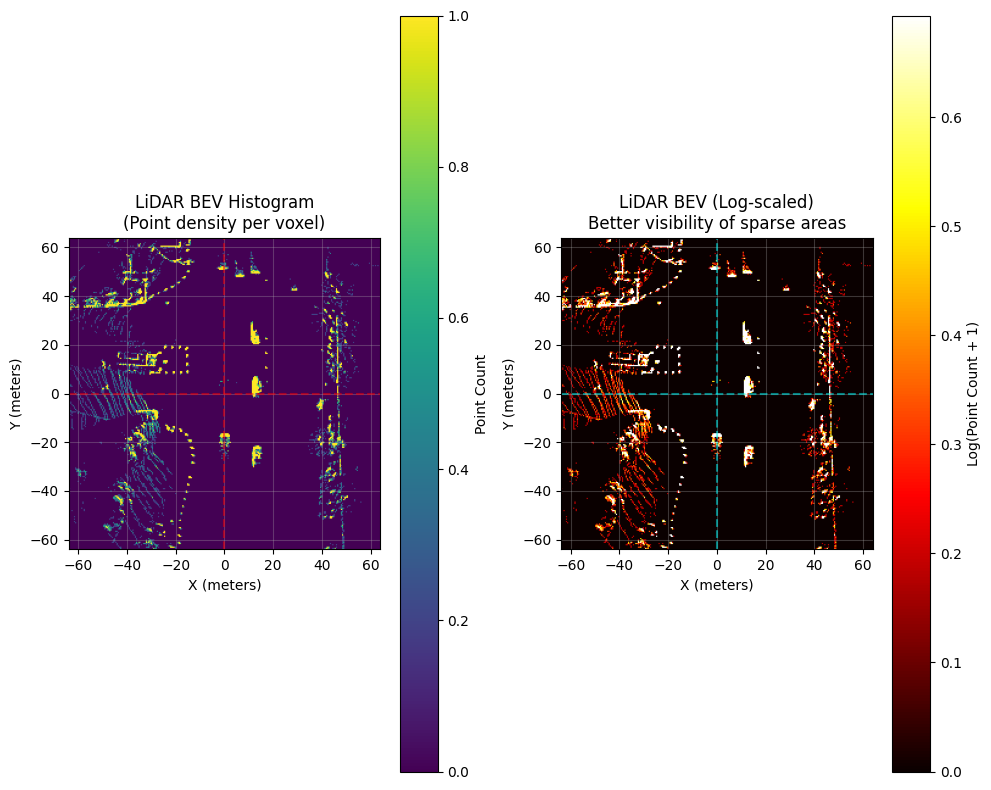

LiDAR BEV Statistics:
  Shape: (256, 256)
  Spatial coverage: 128.0m x 128.0m
  Voxel size: 0.5m
  Non-zero voxels: 5698 / 65536 (8.7%)
  Max points per voxel: 1
  Mean points (non-zero voxels): 0.49


In [26]:
def visualize_lidar_bev(lidar_feature, voxel_size=0.5, figsize=(10, 8)):
    """
    Visualize LiDAR BEV (Bird's Eye View) histogram with proper scaling.
    
    Args:
        lidar_feature: LiDAR feature tensor/array of shape [1, 256, 256]
        voxel_size: Size of each voxel in meters (default 0.5m based on TransFuser)
        figsize: Figure size
    """
    lidar_feat = lidar_feature
    if isinstance(lidar_feat, torch.Tensor):
        lidar_feat = lidar_feat.numpy()
    
    # Remove channel dimension
    lidar_bev = lidar_feat.squeeze(0)
    
    # Calculate the spatial extent
    # TransFuser uses 256x256 grid with 0.5m voxels = 128m x 128m area
    extent_m = 256 * voxel_size / 2  # 64m in each direction
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Original BEV visualization
    im1 = ax1.imshow(lidar_bev, cmap='viridis', origin='lower',
                     extent=[-extent_m, extent_m, -extent_m, extent_m])
    ax1.set_xlabel('X (meters)')
    ax1.set_ylabel('Y (meters)')
    ax1.set_title('LiDAR BEV Histogram\n(Point density per voxel)')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax1.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    plt.colorbar(im1, ax=ax1, label='Point Count')
    
    # Log-scaled visualization for better contrast
    lidar_log = np.log1p(lidar_bev)  # log(1 + x) to handle zeros
    im2 = ax2.imshow(lidar_log, cmap='hot', origin='lower',
                     extent=[-extent_m, extent_m, -extent_m, extent_m])
    ax2.set_xlabel('X (meters)')
    ax2.set_ylabel('Y (meters)')
    ax2.set_title('LiDAR BEV (Log-scaled)\nBetter visibility of sparse areas')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='cyan', linestyle='--', alpha=0.5)
    ax2.axvline(x=0, color='cyan', linestyle='--', alpha=0.5)
    plt.colorbar(im2, ax=ax2, label='Log(Point Count + 1)')
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print(f"LiDAR BEV Statistics:")
    print(f"  Shape: {lidar_bev.shape}")
    print(f"  Spatial coverage: {2*extent_m:.1f}m x {2*extent_m:.1f}m")
    print(f"  Voxel size: {voxel_size}m")
    print(f"  Non-zero voxels: {np.count_nonzero(lidar_bev)} / {lidar_bev.size} ({100*np.count_nonzero(lidar_bev)/lidar_bev.size:.1f}%)")
    print(f"  Max points per voxel: {lidar_bev.max():.0f}")
    print(f"  Mean points (non-zero voxels): {lidar_bev[lidar_bev > 0].mean():.2f}")

# Visualize the LiDAR feature in detail
visualize_lidar_bev(transfuser_feature['lidar_feature'])

## 8. LiDAR BEV Deep Dive
Specialized visualization for LiDAR Bird's Eye View data with proper spatial scaling and statistics.

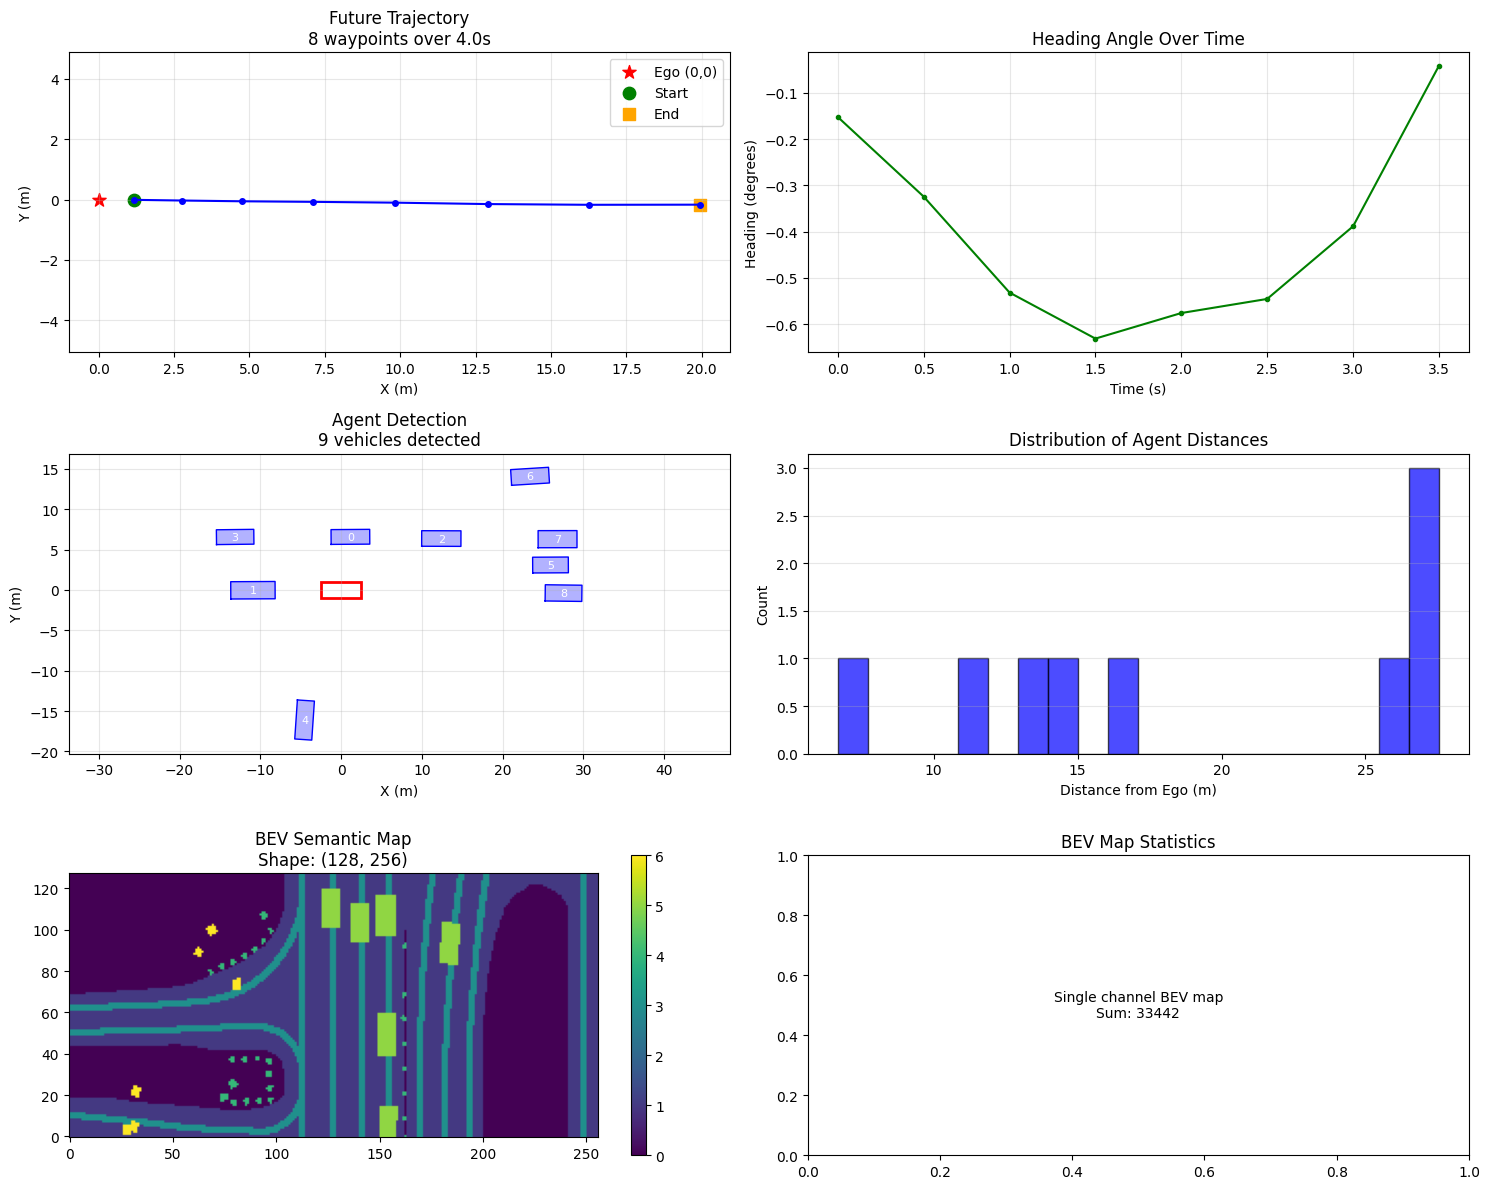


Target Statistics:
Trajectory: 8 waypoints, total distance: 18.76m
Agent States: 30 slots, 9 valid detections
BEV Semantic Map: (128, 256)

Closest agent: 6.68m
Farthest agent: 27.55m


In [27]:
def visualize_transfuser_targets(targets, figsize=(15, 12)):
    """
    Visualize transfuser targets including trajectory, agent states, and BEV semantic map.
    
    Args:
        targets: Dictionary containing 'trajectory', 'agent_states', 'agent_labels', 'bev_semantic_map'
        figsize: Figure size for the plot
    """
    fig = plt.figure(figsize=figsize)
    
    # 1. Visualize Trajectory
    trajectory = targets['trajectory']
    if isinstance(trajectory, torch.Tensor):
        trajectory = trajectory.numpy()
    
    plt.subplot(3, 2, 1)
    # Plot trajectory in 2D (x, y)
    plt.plot(trajectory[:, 0], trajectory[:, 1], 'b.-', markersize=8)
    plt.scatter(0, 0, c='red', s=100, marker='*', label='Ego (0,0)')
    plt.scatter(trajectory[0, 0], trajectory[0, 1], c='green', s=80, marker='o', label='Start')
    plt.scatter(trajectory[-1, 0], trajectory[-1, 1], c='orange', s=80, marker='s', label='End')
    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.title(f'Future Trajectory\n{trajectory.shape[0]} waypoints over {trajectory.shape[0]*0.5:.1f}s')
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.legend()
    
    # 2. Plot heading over time
    plt.subplot(3, 2, 2)
    time_steps = np.arange(len(trajectory)) * 0.5  # 0.5s intervals
    plt.plot(time_steps, np.rad2deg(trajectory[:, 2]), 'g.-')
    plt.xlabel('Time (s)')
    plt.ylabel('Heading (degrees)')
    plt.title('Heading Angle Over Time')
    plt.grid(True, alpha=0.3)
    
    # 3. Visualize Agent States and Labels
    agent_states = targets['agent_states']
    agent_labels = targets['agent_labels']
    if isinstance(agent_states, torch.Tensor):
        agent_states = agent_states.numpy()
    if isinstance(agent_labels, torch.Tensor):
        agent_labels = agent_labels.numpy()
    
    # Filter valid agents (where label is True)
    valid_agents = agent_states[agent_labels]
    
    plt.subplot(3, 2, 3)
    # Plot agent bounding boxes
    ax = plt.gca()
    
    # Plot ego vehicle at origin
    ego_rect = plt.Rectangle((-2.5, -1), 5, 2, 
                           fill=False, edgecolor='red', linewidth=2, label='Ego')
    ax.add_patch(ego_rect)
    
    # Plot other agents - simplified version without rotation transform
    for i, agent in enumerate(valid_agents):
        x, y, heading, length, width = agent
        
        # Draw simple oriented box
        corners = np.array([
            [-length/2, -width/2],
            [length/2, -width/2],
            [length/2, width/2],
            [-length/2, width/2],
            [-length/2, -width/2]
        ])
        
        # Rotate corners
        cos_h = np.cos(heading)
        sin_h = np.sin(heading)
        rotated_corners = np.zeros_like(corners)
        rotated_corners[:, 0] = corners[:, 0] * cos_h - corners[:, 1] * sin_h + x
        rotated_corners[:, 1] = corners[:, 0] * sin_h + corners[:, 1] * cos_h + y
        
        # Plot the box
        plt.plot(rotated_corners[:, 0], rotated_corners[:, 1], 'b-', linewidth=1)
        plt.fill(rotated_corners[:, 0], rotated_corners[:, 1], 'blue', alpha=0.3)
        
        # Add agent number
        plt.text(x, y, str(i), ha='center', va='center', color='white', fontsize=8)
    
    plt.xlim(-64, 64)
    plt.ylim(-64, 64)
    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.title(f'Agent Detection\n{len(valid_agents)} vehicles detected')
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    
    # 4. Agent states histogram
    plt.subplot(3, 2, 4)
    if len(valid_agents) > 0:
        distances = np.sqrt(valid_agents[:, 0]**2 + valid_agents[:, 1]**2)
        plt.hist(distances, bins=20, alpha=0.7, color='blue', edgecolor='black')
        plt.xlabel('Distance from Ego (m)')
        plt.ylabel('Count')
        plt.title('Distribution of Agent Distances')
        plt.grid(axis='y', alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'No agents detected', ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Distribution of Agent Distances')
    
    # 5. Visualize BEV Semantic Map
    bev_map = targets['bev_semantic_map']
    if isinstance(bev_map, torch.Tensor):
        bev_map = bev_map.numpy()
    
    # BEV semantic map has 7 classes based on the code
    class_names = ['Background', 'Road', 'Walkway', 'Vehicles', 'Lane Divider', 
                   'Carpark', 'Pedestrian Crossing']
    
    plt.subplot(3, 2, 5)
    
    # Check the shape of bev_map
    if len(bev_map.shape) == 3:  # Has channel dimension
        # Show RGB visualization by combining first 3 channels
        if bev_map.shape[0] >= 3:
            bev_rgb = bev_map[:3].transpose(1, 2, 0)
            # Normalize for visualization
            bev_rgb = (bev_rgb - bev_rgb.min()) / (bev_rgb.max() - bev_rgb.min() + 1e-8)
            plt.imshow(bev_rgb, origin='lower')
            plt.title(f'BEV Semantic Map (RGB channels)\nShape: {bev_map.shape}')
        else:
            plt.imshow(bev_map[0], cmap='viridis', origin='lower')
            plt.title(f'BEV Semantic Map (Channel 0)\nShape: {bev_map.shape}')
    elif len(bev_map.shape) == 2:  # Single channel
        plt.imshow(bev_map, cmap='viridis', origin='lower')
        plt.title(f'BEV Semantic Map\nShape: {bev_map.shape}')
    else:
        plt.text(0.5, 0.5, f'Unexpected BEV map shape: {bev_map.shape}', 
                ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('BEV Semantic Map')
    
    plt.colorbar()
    
    # 6. Show individual semantic channels
    plt.subplot(3, 2, 6)
    
    if len(bev_map.shape) == 3:
        # Calculate which channels have content
        channel_sums = [bev_map[i].sum() for i in range(bev_map.shape[0])]
        active_channels = [(i, class_names[i] if i < len(class_names) else f'Class {i}', channel_sums[i]) 
                           for i in range(len(channel_sums)) if channel_sums[i] > 0]
        
        if active_channels:
            channels, names, sums = zip(*active_channels)
            plt.bar(range(len(active_channels)), sums)
            plt.xticks(range(len(active_channels)), names, rotation=45, ha='right')
            plt.ylabel('Total Activation')
            plt.title('Semantic Class Activations')
            plt.grid(axis='y', alpha=0.3)
        else:
            plt.text(0.5, 0.5, 'No active semantic channels', ha='center', va='center', 
                    transform=plt.gca().transAxes)
    else:
        plt.text(0.5, 0.5, f'Single channel BEV map\nSum: {bev_map.sum():.0f}', 
                ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('BEV Map Statistics')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\nTarget Statistics:")
    print(f"Trajectory: {trajectory.shape[0]} waypoints, total distance: {np.sum(np.linalg.norm(np.diff(trajectory[:, :2], axis=0), axis=1)):.2f}m")
    print(f"Agent States: {agent_states.shape[0]} slots, {len(valid_agents)} valid detections")
    print(f"BEV Semantic Map: {bev_map.shape}")
    
    if len(valid_agents) > 0:
        print(f"\nClosest agent: {np.min(np.sqrt(valid_agents[:, 0]**2 + valid_agents[:, 1]**2)):.2f}m")
        print(f"Farthest agent: {np.max(np.sqrt(valid_agents[:, 0]**2 + valid_agents[:, 1]**2)):.2f}m")

# Visualize the targets
visualize_transfuser_targets(transfuser_target)

## 9. Comprehensive Target Visualization
Function to visualize all ground truth targets:
- Trajectory: Future waypoints over 4 seconds
- Agent states: Detected vehicles with bounding boxes
- BEV semantic map: Road segmentation (note: appears to be single channel in this data)

In [28]:
# First, let's check what we have in the targets
print("Checking target shapes:")
for key, value in transfuser_target.items():
    if hasattr(value, 'shape'):
        print(f"{key}: {value.shape}")
    else:
        print(f"{key}: {type(value)}")

Checking target shapes:
trajectory: torch.Size([8, 3])
agent_states: torch.Size([30, 5])
agent_labels: torch.Size([30])
bev_semantic_map: torch.Size([128, 256])


## 10. BEV Semantic Map Analysis
Investigate the BEV semantic map structure and channels.

BEV semantic map info:
  Shape: torch.Size([128, 256])
  Type: <class 'torch.Tensor'>
  Dtype: torch.float32
BEV map shape: (128, 256)
BEV map dtype: float32


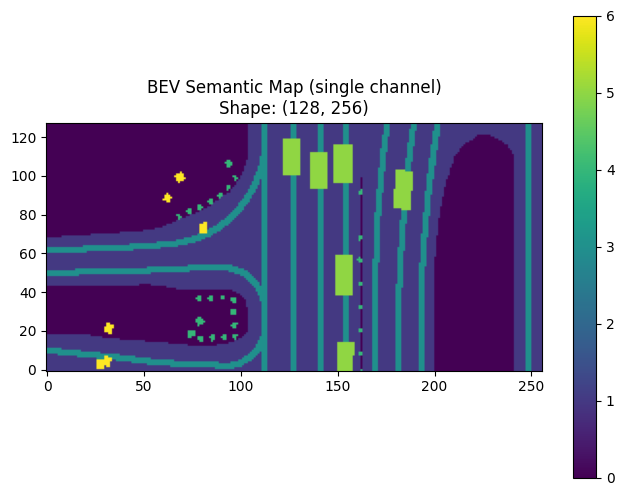

In [29]:
def visualize_bev_semantic_channels(bev_map, figsize=(15, 10)):
    """
    Visualize each semantic channel of the BEV map individually.
    
    Args:
        bev_map: BEV semantic map tensor/array of shape [7, H, W]
        figsize: Figure size
    """
    if isinstance(bev_map, torch.Tensor):
        bev_map = bev_map.numpy()
    
    print(f"BEV map shape: {bev_map.shape}")
    print(f"BEV map dtype: {bev_map.dtype}")
    
    # Handle different shapes
    if len(bev_map.shape) == 1:
        # If 1D, try to reshape to square
        size = int(np.sqrt(bev_map.shape[0]))
        if size * size == bev_map.shape[0]:
            print(f"Reshaping 1D array ({bev_map.shape[0]}) to 2D ({size}x{size})")
            bev_map = bev_map.reshape(size, size)
            # Treat as single channel
            plt.figure(figsize=(8, 6))
            plt.imshow(bev_map, cmap='viridis', origin='lower')
            plt.title(f'BEV Semantic Map (reshaped from 1D)\nShape: {bev_map.shape}')
            plt.colorbar()
            plt.show()
            return
        else:
            print(f"Cannot reshape 1D array of size {bev_map.shape[0]} to square")
            return
    
    elif len(bev_map.shape) == 2:
        # Single channel 2D map
        plt.figure(figsize=(8, 6))
        plt.imshow(bev_map, cmap='viridis', origin='lower')
        plt.title(f'BEV Semantic Map (single channel)\nShape: {bev_map.shape}')
        plt.colorbar()
        plt.show()
        return
    
    # Multi-channel case (3D)
    # Semantic classes from transfuser_features.py
    class_names = [
        'Background',      # 0
        'Road',           # 1  
        'Walkway',        # 2
        'Vehicles',       # 3
        'Lane Divider',   # 4
        'Carpark',        # 5
        'Ped Crossing'    # 6
    ]
    
    n_classes = bev_map.shape[0]
    n_cols = 3
    n_rows = (n_classes + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for i in range(n_classes):
        ax = axes[i]
        channel = bev_map[i]
        
        # Check if channel is 2D
        if len(channel.shape) != 2:
            ax.text(0.5, 0.5, f'Channel {i} has shape {channel.shape}', 
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'Invalid channel {i}')
            ax.axis('off')
            continue
        
        # Use different colormaps for different classes
        if i == 0:  # Background
            cmap = 'gray'
        elif i == 1:  # Road
            cmap = 'Blues'
        elif i == 2:  # Walkway
            cmap = 'Oranges'
        elif i == 3:  # Vehicles
            cmap = 'Reds'
        elif i == 4:  # Lane Divider
            cmap = 'Greens'
        elif i == 5:  # Carpark
            cmap = 'Purples'
        else:  # Pedestrian Crossing
            cmap = 'YlOrBr'
            
        im = ax.imshow(channel, cmap=cmap, origin='lower')
        
        # Add title with statistics
        title = f'{class_names[i] if i < len(class_names) else f"Class {i}"}'
        if channel.sum() > 0:
            title += f'\nMax: {channel.max():.2f}, Sum: {channel.sum():.0f}'
        else:
            title += '\n(Empty)'
            
        ax.set_title(title)
        ax.axis('off')
        
        # Add colorbar for non-empty channels
        if channel.sum() > 0:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    # Hide unused subplots
    for i in range(n_classes, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'BEV Semantic Map Channels\nShape: {bev_map.shape}', fontsize=14)
    plt.tight_layout()
    plt.show()

# First check the shape
if 'bev_semantic_map' in transfuser_target:
    print("BEV semantic map info:")
    bev = transfuser_target['bev_semantic_map']
    if hasattr(bev, 'shape'):
        print(f"  Shape: {bev.shape}")
        print(f"  Type: {type(bev)}")
        if hasattr(bev, 'dtype'):
            print(f"  Dtype: {bev.dtype}")
    
    # Visualize individual BEV channels
    visualize_bev_semantic_channels(transfuser_target['bev_semantic_map'])
else:
    print("No bev_semantic_map found in targets")

## 11. BEV Semantic Channel Visualization
Detailed visualization of individual semantic channels (if multi-channel).

In [30]:
def load_and_visualize_sequence(cache_dir, log_name, start_token, num_frames=5):
    """
    Load and visualize a sequence of features from the cache.
    
    Args:
        cache_dir: Base cache directory
        log_name: Log folder name
        start_token: Starting token
        num_frames: Number of frames to visualize
    """
    # Find feature files
    log_path = cache_dir / log_name
    feature_files = sorted(log_path.glob("transfuser_feature_*.gz"))
    
    # Find the starting index
    start_idx = None
    for i, f in enumerate(feature_files):
        if start_token in f.name:
            start_idx = i
            break
    
    if start_idx is None:
        print(f"Token {start_token} not found")
        return
    
    # Load features
    features_list = []
    for i in range(start_idx, min(start_idx + num_frames, len(feature_files))):
        with gzip.open(feature_files[i], 'rb') as f:
            features_list.append(pickle.load(f))
    
    # Create visualization
    fig = plt.figure(figsize=(20, 4 * len(features_list)))
    
    for idx, features in enumerate(features_list):
        # Camera
        ax1 = plt.subplot(len(features_list), 4, idx * 4 + 1)
        camera_img = np.transpose(features['camera_feature'].numpy(), (1, 2, 0))
        if camera_img.max() > 1.0:
            camera_img = (camera_img - camera_img.min()) / (camera_img.max() - camera_img.min())
        ax1.imshow(camera_img)
        ax1.set_title(f'Frame {idx}: Camera')
        ax1.axis('off')
        
        # LiDAR
        ax2 = plt.subplot(len(features_list), 4, idx * 4 + 2)
        lidar_img = features['lidar_feature'].numpy().squeeze(0)
        ax2.imshow(np.log1p(lidar_img), cmap='hot', origin='lower')
        ax2.set_title(f'Frame {idx}: LiDAR (log)')
        ax2.axis('off')
        
        # Status
        ax3 = plt.subplot(len(features_list), 4, idx * 4 + 3)
        status = features['status_feature'].numpy()
        labels_short = ['vx', 'vy', 'ax', 'ay', 'stop', 'left', 'right', 'straight']
        colors = ['b', 'b', 'g', 'g', 'r', 'orange', 'orange', 'orange']
        ax3.bar(range(8), status, color=colors)
        ax3.set_xticks(range(8))
        ax3.set_xticklabels(labels_short, rotation=45)
        ax3.set_title(f'Frame {idx}: Status')
        ax3.grid(axis='y', alpha=0.3)
        
        # Driving command interpretation
        ax4 = plt.subplot(len(features_list), 4, idx * 4 + 4)
        cmd_idx = np.argmax(status[4:8])
        cmd_names = ['STOP', 'LEFT', 'RIGHT', 'STRAIGHT']
        ax4.text(0.5, 0.7, f'Command: {cmd_names[cmd_idx]}', 
                ha='center', va='center', fontsize=16, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue'))
        ax4.text(0.5, 0.3, f'Velocity: ({status[0]:.1f}, {status[1]:.1f}) m/s\nAccel: ({status[2]:.1f}, {status[3]:.1f}) m/s²', 
                ha='center', va='center', fontsize=12)
        ax4.set_xlim(0, 1)
        ax4.set_ylim(0, 1)
        ax4.axis('off')
    
    plt.tight_layout()
    plt.show()

# Example: Load a sequence (you'll need to adjust the path and token)
# load_and_visualize_sequence(base_cache_dir, "log_folder_name", "token_string", num_frames=3)

## 12. Sequence Data Organization (Not Used)
Template function for loading sequences - kept for reference but not used in current analysis.

In [31]:
# Add path exploration for cached data sequences
cache_base_dir = Path("/workspace/navsim_workspace/exp/training_cache/")

# List all sequences
sequences = sorted([d for d in cache_base_dir.iterdir() if d.is_dir()])
print(f"Total sequences: {len(sequences)}")
print("\nFirst 10 sequences:")
for seq in sequences[:10]:
    print(f"  {seq.name}")

# Count tokens in the first sequence
first_seq = sequences[0]
tokens = sorted([d for d in first_seq.iterdir() if d.is_dir()])
print(f"\nFirst sequence '{first_seq.name}' has {len(tokens)} tokens")
print("Token examples:")
for token in tokens[:5]:
    print(f"  {token.name}")

Total sequences: 1192

First 10 sequences:
  2021.05.12.19.36.12_veh-35_00005_00204
  2021.05.12.19.36.12_veh-35_00215_00405
  2021.05.12.19.36.12_veh-35_00416_00557
  2021.05.12.19.36.12_veh-35_00568_01168
  2021.05.12.19.36.12_veh-35_01179_01278
  2021.05.12.19.36.12_veh-35_01400_01643
  2021.05.12.19.36.12_veh-35_01744_01934
  2021.05.12.19.36.12_veh-35_01945_02065
  2021.05.12.19.36.12_veh-35_02079_02176
  2021.05.12.22.00.38_veh-35_00005_00118

First sequence '2021.05.12.19.36.12_veh-35_00005_00204' has 6 tokens
Token examples:
  0a678d2136b35b56
  153c6b07f09d53d1
  1aa44d46e4ab5bc7
  2570fbfdf1835706
  c59175106e2f5b26


## 13. Cache Directory Exploration
List all sequences in the training cache and count tokens per sequence.

Sequence: 2021.05.12.19.36.12_veh-35_00005_00204
Total tokens: 6


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


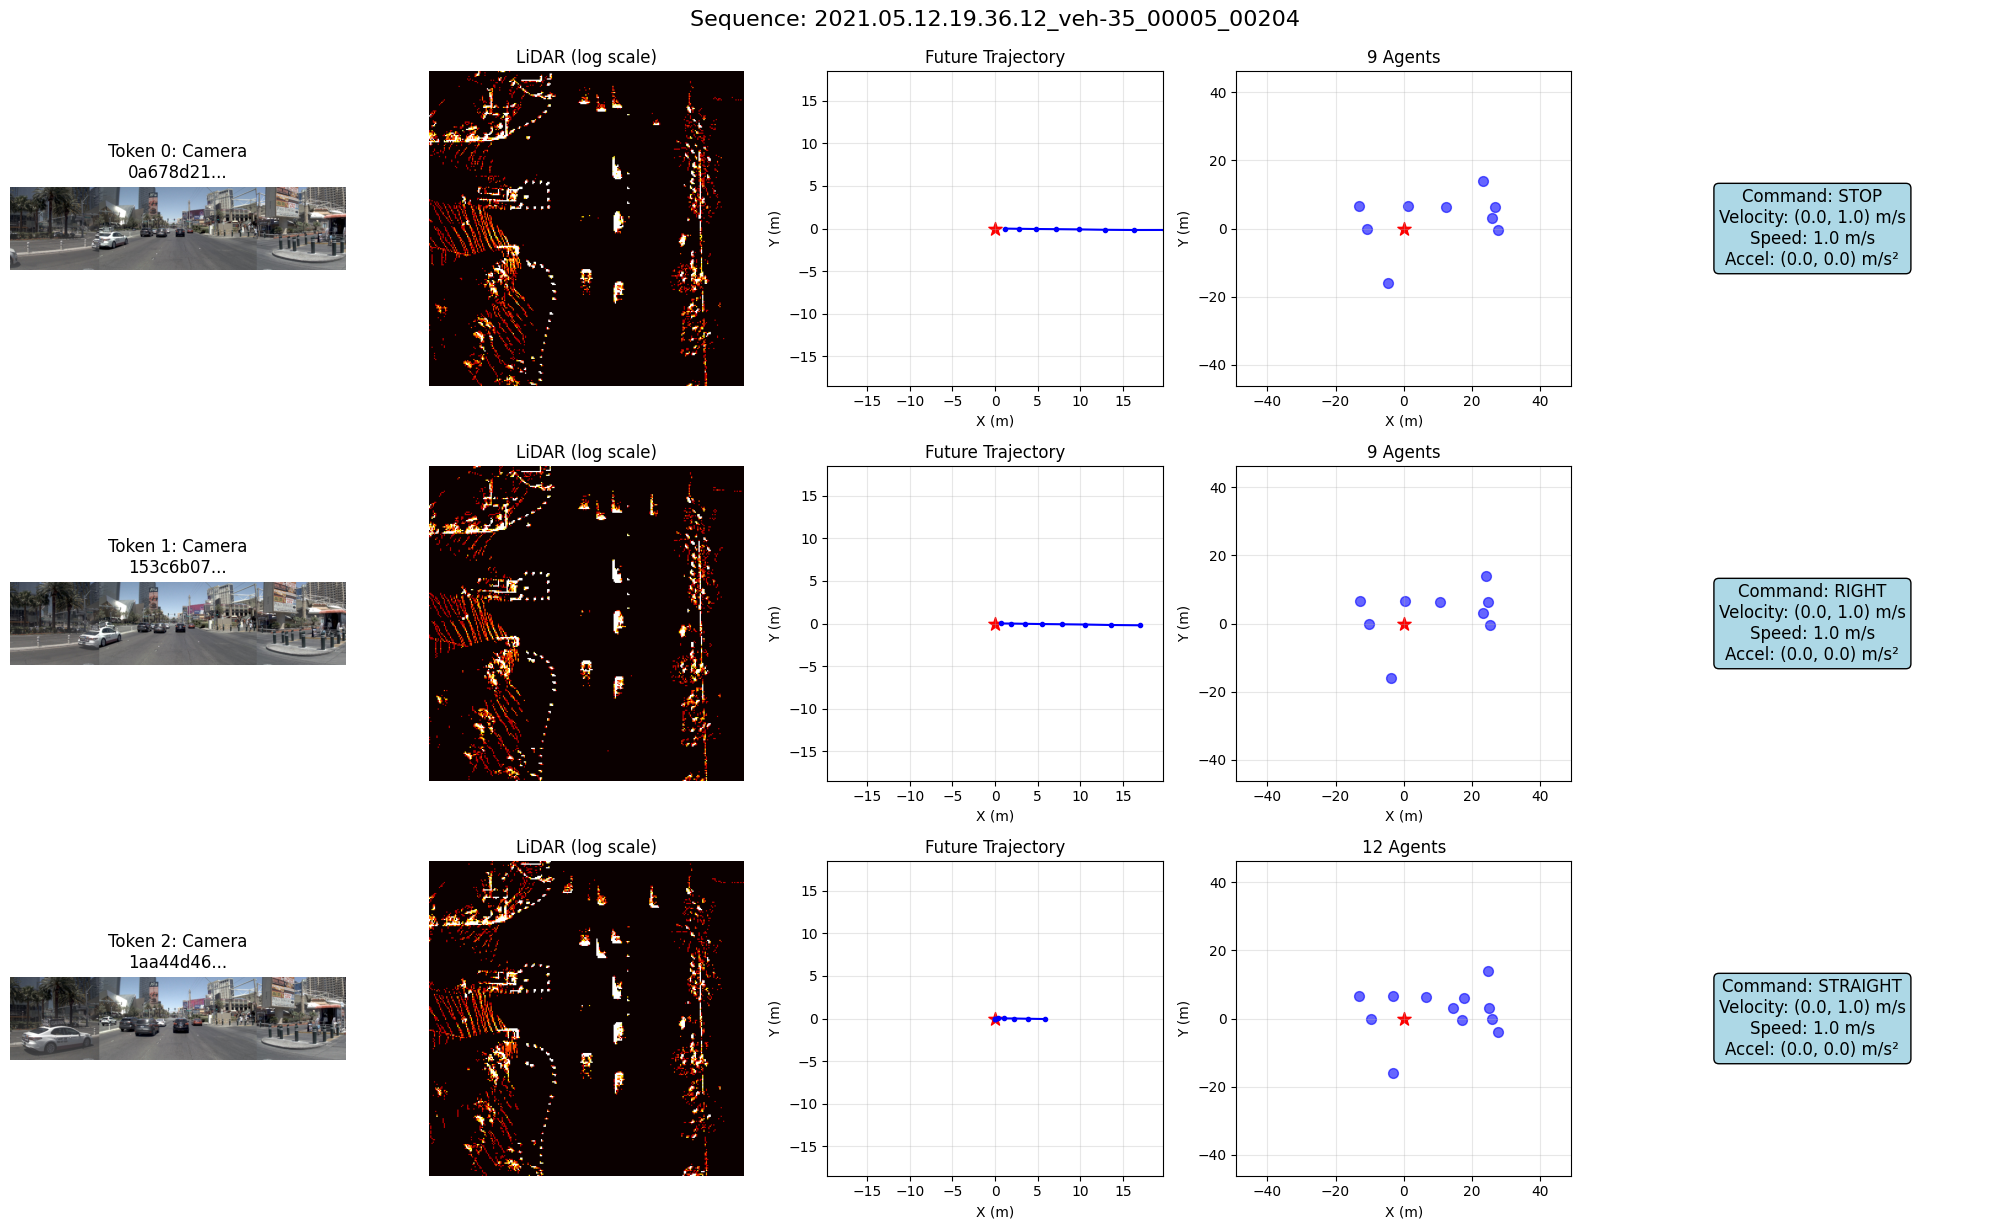

In [32]:
def explore_sequence(sequence_name, num_tokens=5):
    """
    Explore a specific sequence by loading and visualizing multiple tokens.
    
    Args:
        sequence_name: Name of the sequence folder
        num_tokens: Number of tokens to visualize
    """
    seq_path = cache_base_dir / sequence_name
    if not seq_path.exists():
        print(f"Sequence {sequence_name} not found!")
        return
    
    tokens = sorted([d for d in seq_path.iterdir() if d.is_dir()])
    print(f"Sequence: {sequence_name}")
    print(f"Total tokens: {len(tokens)}")
    
    # Load and visualize tokens
    fig = plt.figure(figsize=(20, 4 * min(num_tokens, len(tokens))))
    
    for idx in range(min(num_tokens, len(tokens))):
        token_path = tokens[idx]
        feature_file = token_path / "transfuser_feature.gz"
        target_file = token_path / "transfuser_target.gz"
        
        if not feature_file.exists() or not target_file.exists():
            print(f"Missing files for token {token_path.name}")
            continue
            
        # Load feature
        with gzip.open(feature_file, 'rb') as f:
            features = pickle.load(f)
        
        # Load target
        with gzip.open(target_file, 'rb') as f:
            targets = pickle.load(f)
        
        # Plot camera image
        ax1 = plt.subplot(min(num_tokens, len(tokens)), 5, idx * 5 + 1)
        camera_img = np.transpose(features['camera_feature'].numpy(), (1, 2, 0))
        if camera_img.max() > 1.0:
            camera_img = (camera_img - camera_img.min()) / (camera_img.max() - camera_img.min())
        ax1.imshow(camera_img)
        ax1.set_title(f'Token {idx}: Camera\n{token_path.name[:8]}...')
        ax1.axis('off')
        
        # Plot LiDAR
        ax2 = plt.subplot(min(num_tokens, len(tokens)), 5, idx * 5 + 2)
        lidar_img = features['lidar_feature'].numpy().squeeze(0)
        ax2.imshow(np.log1p(lidar_img), cmap='hot', origin='lower')
        ax2.set_title(f'LiDAR (log scale)')
        ax2.axis('off')
        
        # Plot trajectory
        ax3 = plt.subplot(min(num_tokens, len(tokens)), 5, idx * 5 + 3)
        traj = targets['trajectory'].numpy()
        ax3.plot(traj[:, 0], traj[:, 1], 'b.-', markersize=6)
        ax3.scatter(0, 0, c='red', s=100, marker='*')
        ax3.set_xlabel('X (m)')
        ax3.set_ylabel('Y (m)')
        ax3.set_title('Future Trajectory')
        ax3.grid(True, alpha=0.3)
        ax3.axis('equal')
        ax3.set_xlim(-20, 20)
        ax3.set_ylim(-20, 20)
        
        # Plot agents
        ax4 = plt.subplot(min(num_tokens, len(tokens)), 5, idx * 5 + 4)
        agent_states = targets['agent_states'].numpy()
        agent_labels = targets['agent_labels'].numpy()
        valid_agents = agent_states[agent_labels]
        
        if len(valid_agents) > 0:
            ax4.scatter(valid_agents[:, 0], valid_agents[:, 1], c='blue', s=50, alpha=0.6)
        ax4.scatter(0, 0, c='red', s=100, marker='*', label='Ego')
        ax4.set_xlabel('X (m)')
        ax4.set_ylabel('Y (m)')
        ax4.set_title(f'{len(valid_agents)} Agents')
        ax4.grid(True, alpha=0.3)
        ax4.axis('equal')
        ax4.set_xlim(-50, 50)
        ax4.set_ylim(-50, 50)
        
        # Plot driving command and velocity
        ax5 = plt.subplot(min(num_tokens, len(tokens)), 5, idx * 5 + 5)
        status = features['status_feature'].numpy()
        
        # The status feature has 8 elements: [vx, vy, ax, ay, stop, left, right, straight]
        vx, vy, ax, ay = status[0], status[1], status[2], status[3]
        commands = status[4:8]
        cmd_names = ['STOP', 'LEFT', 'RIGHT', 'STRAIGHT']
        active_cmd = np.argmax(commands)
        
        info_text = f"Command: {cmd_names[active_cmd]}\n"
        info_text += f"Velocity: ({vx:.1f}, {vy:.1f}) m/s\n"
        info_text += f"Speed: {np.sqrt(vx**2 + vy**2):.1f} m/s\n"
        info_text += f"Accel: ({ax:.1f}, {ay:.1f}) m/s²"
        
        ax5.text(0.5, 0.5, info_text, ha='center', va='center', 
                fontsize=12, transform=ax5.transAxes,
                bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue'))
        ax5.axis('off')
    
    plt.tight_layout()
    plt.suptitle(f'Sequence: {sequence_name}', fontsize=16, y=1.02)
    plt.show()

# Example: Explore the first sequence
if sequences:
    explore_sequence(sequences[0].name, num_tokens=3)

## 14. Sequence Exploration Tool
Function to explore a specific sequence by visualizing multiple consecutive tokens with all their features and targets side by side.

Analyzing sequence: 2021.05.12.19.36.12_veh-35_00005_00204
Tokens 0 to 4 (of 6 total)


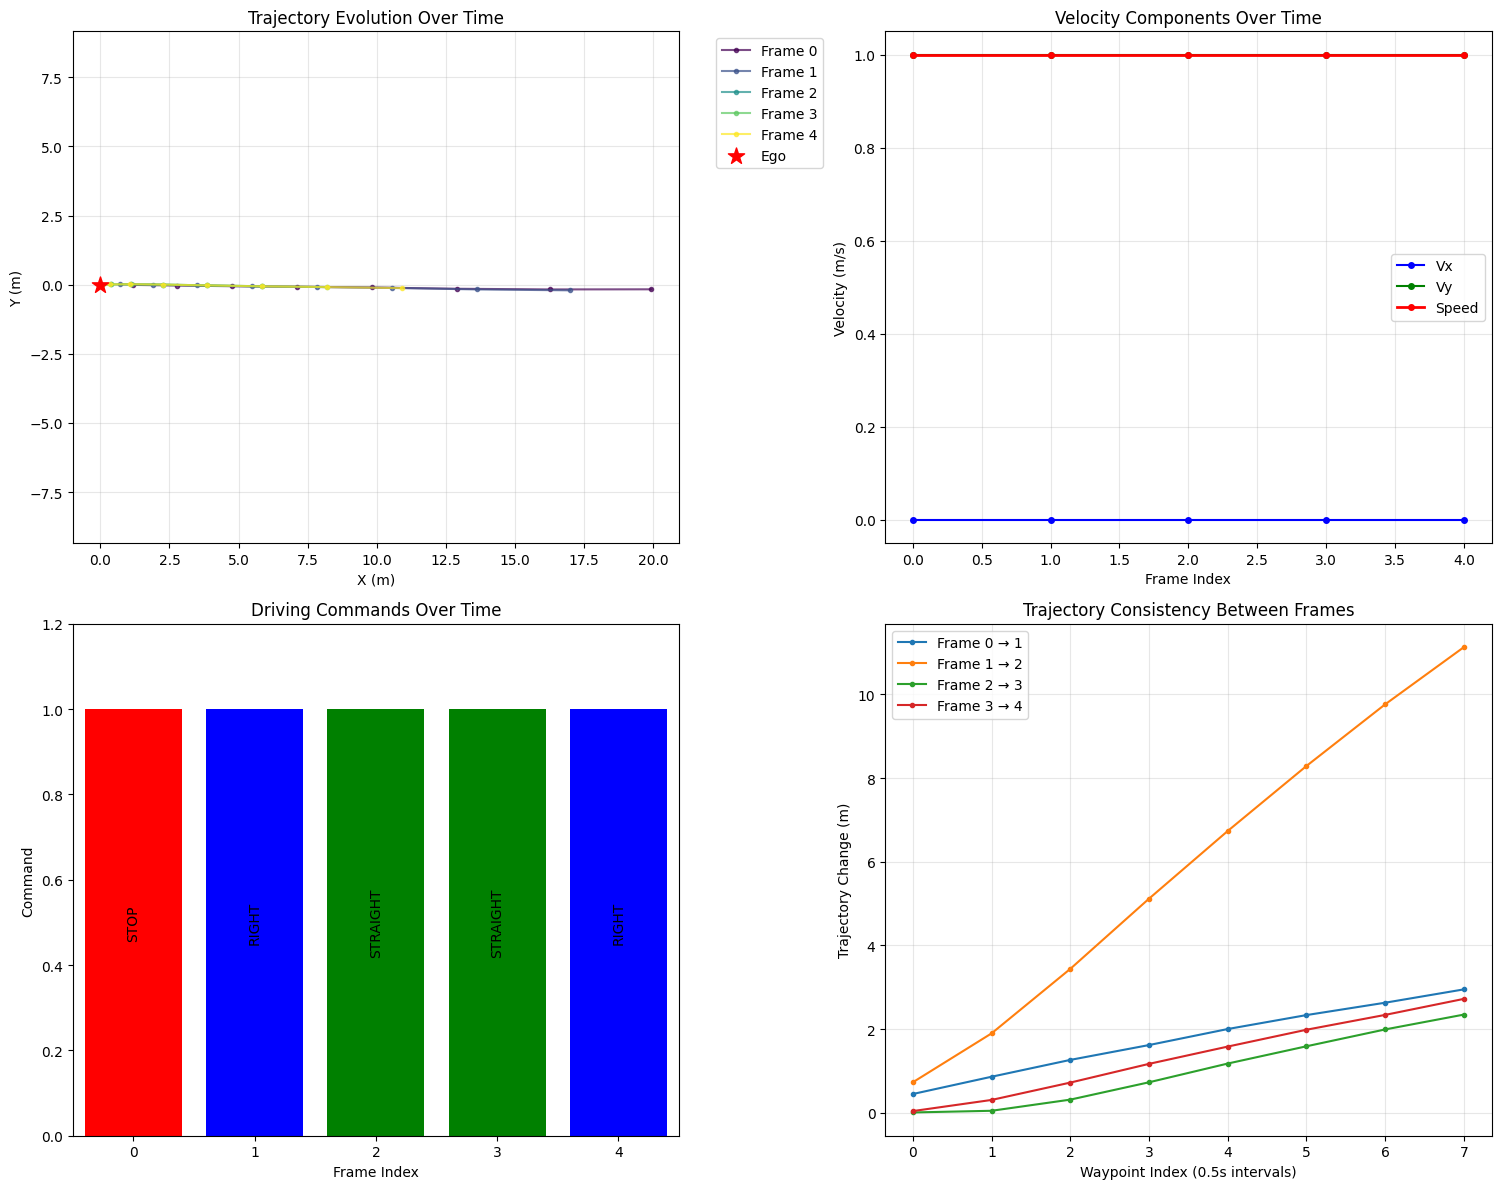


Summary Statistics:
Average speed: 1.00 m/s
Speed range: [1.00, 1.00] m/s
Command distribution: {'STOP': 1, 'LEFT': 0, 'RIGHT': 2, 'STRAIGHT': 2}


In [33]:
def analyze_temporal_sequence(sequence_name, start_idx=0, num_frames=5):
    """
    Analyze temporal relationships between consecutive frames in a sequence.
    
    Args:
        sequence_name: Name of the sequence folder
        start_idx: Starting token index
        num_frames: Number of consecutive frames to analyze
    """
    seq_path = cache_base_dir / sequence_name
    if not seq_path.exists():
        print(f"Sequence {sequence_name} not found!")
        return
    
    tokens = sorted([d for d in seq_path.iterdir() if d.is_dir()])
    print(f"Analyzing sequence: {sequence_name}")
    print(f"Tokens {start_idx} to {start_idx + num_frames - 1} (of {len(tokens)} total)")
    
    # Collect data from consecutive frames
    trajectories = []
    velocities = []
    commands = []
    
    for i in range(start_idx, min(start_idx + num_frames, len(tokens))):
        token_path = tokens[i]
        
        # Load feature and target
        with gzip.open(token_path / "transfuser_feature.gz", 'rb') as f:
            features = pickle.load(f)
        with gzip.open(token_path / "transfuser_target.gz", 'rb') as f:
            targets = pickle.load(f)
        
        traj = targets['trajectory'].numpy()
        status = features['status_feature'].numpy()
        
        trajectories.append(traj)
        velocities.append([status[0], status[1]])  # vx, vy
        commands.append(np.argmax(status[4:8]))
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Overlay all trajectories
    ax1 = axes[0, 0]
    colors = plt.cm.viridis(np.linspace(0, 1, len(trajectories)))
    for i, (traj, color) in enumerate(zip(trajectories, colors)):
        ax1.plot(traj[:, 0], traj[:, 1], '.-', color=color, 
                label=f'Frame {start_idx + i}', markersize=6, alpha=0.7)
    ax1.scatter(0, 0, c='red', s=150, marker='*', label='Ego', zorder=10)
    ax1.set_xlabel('X (m)')
    ax1.set_ylabel('Y (m)')
    ax1.set_title('Trajectory Evolution Over Time')
    ax1.grid(True, alpha=0.3)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.axis('equal')
    
    # 2. Velocity profile over time
    ax2 = axes[0, 1]
    velocities = np.array(velocities)
    speeds = np.sqrt(velocities[:, 0]**2 + velocities[:, 1]**2)
    frame_indices = np.arange(start_idx, start_idx + len(velocities))
    
    ax2.plot(frame_indices, velocities[:, 0], 'b.-', label='Vx', markersize=8)
    ax2.plot(frame_indices, velocities[:, 1], 'g.-', label='Vy', markersize=8)
    ax2.plot(frame_indices, speeds, 'r.-', label='Speed', markersize=8, linewidth=2)
    ax2.set_xlabel('Frame Index')
    ax2.set_ylabel('Velocity (m/s)')
    ax2.set_title('Velocity Components Over Time')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # 3. Command sequence
    ax3 = axes[1, 0]
    cmd_names = ['STOP', 'LEFT', 'RIGHT', 'STRAIGHT']
    cmd_colors = ['red', 'orange', 'blue', 'green']
    
    for i, cmd in enumerate(commands):
        ax3.bar(start_idx + i, 1, color=cmd_colors[cmd], width=0.8)
        ax3.text(start_idx + i, 0.5, cmd_names[cmd], 
                ha='center', va='center', rotation=90, fontsize=10)
    
    ax3.set_xlabel('Frame Index')
    ax3.set_ylabel('Command')
    ax3.set_title('Driving Commands Over Time')
    ax3.set_ylim(0, 1.2)
    ax3.set_xlim(start_idx - 0.5, start_idx + len(commands) - 0.5)
    
    # 4. Trajectory consistency analysis
    ax4 = axes[1, 1]
    
    # Calculate trajectory differences between consecutive frames
    if len(trajectories) > 1:
        diffs = []
        for i in range(1, len(trajectories)):
            # Calculate how much the predicted trajectory changed
            diff = np.linalg.norm(trajectories[i] - trajectories[i-1], axis=1)
            diffs.append(diff)
        
        diffs = np.array(diffs)
        waypoint_indices = np.arange(diffs.shape[1])
        
        for i, diff in enumerate(diffs):
            ax4.plot(waypoint_indices, diff, '.-', 
                    label=f'Frame {start_idx + i} → {start_idx + i + 1}')
        
        ax4.set_xlabel('Waypoint Index (0.5s intervals)')
        ax4.set_ylabel('Trajectory Change (m)')
        ax4.set_title('Trajectory Consistency Between Frames')
        ax4.grid(True, alpha=0.3)
        ax4.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nSummary Statistics:")
    print(f"Average speed: {np.mean(speeds):.2f} m/s")
    print(f"Speed range: [{np.min(speeds):.2f}, {np.max(speeds):.2f}] m/s")
    print(f"Command distribution: {dict(zip(cmd_names, np.bincount(commands, minlength=4)))}")

# Example: Analyze temporal sequence
if sequences:
    analyze_temporal_sequence(sequences[0].name, start_idx=0, num_frames=5)

## 15. Temporal Consistency Analysis
Function to analyze how predictions and states evolve over consecutive frames in a sequence:
- Trajectory evolution
- Velocity profiles
- Command sequences
- Trajectory consistency between frames

In [34]:
def find_scenarios(scenario_type="turn", num_examples=5, max_sequences=20):
    """
    Find sequences containing specific scenario types.
    
    Args:
        scenario_type: Type of scenario to find ("turn", "stop", "high_speed", "crowded")
        num_examples: Number of example sequences to return
        max_sequences: Maximum number of sequences to search
    """
    found_scenarios = []
    
    print(f"Searching for '{scenario_type}' scenarios...")
    
    for seq_idx, seq_path in enumerate(sequences[:max_sequences]):
        tokens = sorted([d for d in seq_path.iterdir() if d.is_dir()])
        
        for token_idx, token_path in enumerate(tokens[:10]):  # Check first 10 tokens
            try:
                # Load data
                with gzip.open(token_path / "transfuser_feature.gz", 'rb') as f:
                    features = pickle.load(f)
                with gzip.open(token_path / "transfuser_target.gz", 'rb') as f:
                    targets = pickle.load(f)
                
                status = features['status_feature'].numpy()
                traj = targets['trajectory'].numpy()
                agent_states = targets['agent_states'].numpy()
                agent_labels = targets['agent_labels'].numpy()
                
                # Extract info
                vx, vy = status[0], status[1]
                speed = np.sqrt(vx**2 + vy**2)
                cmd = np.argmax(status[4:8])
                cmd_names = ['STOP', 'LEFT', 'RIGHT', 'STRAIGHT']
                num_agents = np.sum(agent_labels)
                
                # Check scenario conditions
                found = False
                scenario_info = {}
                
                if scenario_type == "turn":
                    # Look for left or right turns
                    if cmd in [1, 2]:  # LEFT or RIGHT
                        found = True
                        scenario_info = {
                            'command': cmd_names[cmd],
                            'speed': speed,
                            'trajectory_curvature': np.std(traj[:, 1])  # Simple curvature measure
                        }
                
                elif scenario_type == "stop":
                    # Look for stop scenarios
                    if cmd == 0 or speed < 0.5:
                        found = True
                        scenario_info = {
                            'command': cmd_names[cmd],
                            'speed': speed,
                            'deceleration': status[2]  # ax
                        }
                
                elif scenario_type == "high_speed":
                    # Look for high-speed scenarios
                    if speed > 10.0:  # > 10 m/s
                        found = True
                        scenario_info = {
                            'speed': speed,
                            'command': cmd_names[cmd]
                        }
                
                elif scenario_type == "crowded":
                    # Look for scenarios with many agents
                    if num_agents > 5:
                        found = True
                        scenario_info = {
                            'num_agents': num_agents,
                            'speed': speed,
                            'command': cmd_names[cmd]
                        }
                
                if found:
                    found_scenarios.append({
                        'sequence': seq_path.name,
                        'token_idx': token_idx,
                        'token': token_path.name,
                        'info': scenario_info
                    })
                    
                    if len(found_scenarios) >= num_examples:
                        break
                        
            except Exception as e:
                continue
        
        if len(found_scenarios) >= num_examples:
            break
    
    # Display results
    print(f"\nFound {len(found_scenarios)} '{scenario_type}' scenarios:")
    for i, scenario in enumerate(found_scenarios):
        print(f"\n{i+1}. Sequence: {scenario['sequence']}")
        print(f"   Token index: {scenario['token_idx']}")
        print(f"   Info: {scenario['info']}")
    
    return found_scenarios

# Find different types of scenarios
turn_scenarios = find_scenarios("turn", num_examples=3)
print("\n" + "="*50 + "\n")
stop_scenarios = find_scenarios("stop", num_examples=3)
print("\n" + "="*50 + "\n")
crowded_scenarios = find_scenarios("crowded", num_examples=3)

Searching for 'turn' scenarios...

Found 3 'turn' scenarios:

1. Sequence: 2021.05.12.19.36.12_veh-35_00005_00204
   Token index: 1
   Info: {'command': 'RIGHT', 'speed': 1.0, 'trajectory_curvature': 0.07278422773571745}

2. Sequence: 2021.05.12.19.36.12_veh-35_00005_00204
   Token index: 4
   Info: {'command': 'RIGHT', 'speed': 1.0, 'trajectory_curvature': 0.048272883494278926}

3. Sequence: 2021.05.12.19.36.12_veh-35_00005_00204
   Token index: 5
   Info: {'command': 'RIGHT', 'speed': 1.0, 'trajectory_curvature': 0.06661909688151553}


Searching for 'stop' scenarios...

Found 3 'stop' scenarios:

1. Sequence: 2021.05.12.19.36.12_veh-35_00005_00204
   Token index: 0
   Info: {'command': 'STOP', 'speed': 1.0, 'deceleration': 0.0}

2. Sequence: 2021.05.12.19.36.12_veh-35_00215_00405
   Token index: 0
   Info: {'command': 'STOP', 'speed': 1.0, 'deceleration': 0.0}

3. Sequence: 2021.05.12.19.36.12_veh-35_00215_00405
   Token index: 1
   Info: {'command': 'STOP', 'speed': 1.0, 'decelerati

## 16. Scenario Search Tool
Function to search the dataset for specific driving scenarios:
- Turn scenarios (LEFT/RIGHT commands)
- Stop scenarios (STOP command or low speed)
- High-speed scenarios (> 10 m/s)
- Crowded scenarios (> 5 detected agents)

## Data Exploration Summary

This notebook provides tools to explore the CARLA-NavSim cached training data. The data is organized as:

```
/workspace/navsim_workspace/exp/training_cache/
├── [sequence_name]/          # e.g., 2021.05.12.19.36.12_veh-35_00005_00204
│   ├── [token_id]/          # e.g., 0a678d2136b35b56
│   │   ├── transfuser_feature.gz
│   │   └── transfuser_target.gz
```

### Data Structure:

**Features** (transfuser_feature.gz):
- `camera_feature`: [3, 256, 1024] - RGB stitched from 3 front cameras
- `lidar_feature`: [1, 256, 256] - BEV LiDAR histogram
- `status_feature`: [8] - [vx, vy, ax, ay, stop, left, right, straight]

**Targets** (transfuser_target.gz):
- `trajectory`: [8, 3] - Future waypoints (x, y, heading) at 0.5s intervals
- `agent_states`: [30, 5] - Other vehicles (x, y, heading, length, width)
- `agent_labels`: [30] - Boolean mask for valid agents
- `bev_semantic_map`: [128, 256] - BEV segmentation (single channel in this data)

### Usage Examples:

1. **Explore a specific sequence:**
   ```python
   explore_sequence("2021.05.12.19.36.12_veh-35_00005_00204", num_tokens=5)
   ```

2. **Analyze temporal consistency:**
   ```python
   analyze_temporal_sequence("2021.05.12.19.36.12_veh-35_00005_00204", start_idx=0, num_frames=5)
   ```

3. **Find specific scenarios:**
   ```python
   scenarios = find_scenarios("turn", num_examples=5)
   scenarios = find_scenarios("stop", num_examples=5)
   scenarios = find_scenarios("crowded", num_examples=5)
   ```

4. **Visualize a single sample:**
   - Use `visualize_transfuser_features()` for features
   - Use `visualize_transfuser_targets()` for targets

Note: The status feature format is [vx, vy, ax, ay, stop, left, right, straight] based on the actual data,
not the comment in the original notebook which incorrectly stated the command comes first.